# Euler Angles

Euler angles are three angular parameters that describe the orientation of a rigid body in three-dimensional space. These angles represent a sequence of rotations around the axes of a coordinate system and allow the transformation of the orientation of one reference frame relative to another. The three Euler angles correspond to rotations about specific axes in a defined order, and their combination fully defines the orientation of the object.

In [ ]:
!pip install numpy sympy matplotlib

import numpy as np
import sympy as sm
from sympy.physics.vector import *
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation

---

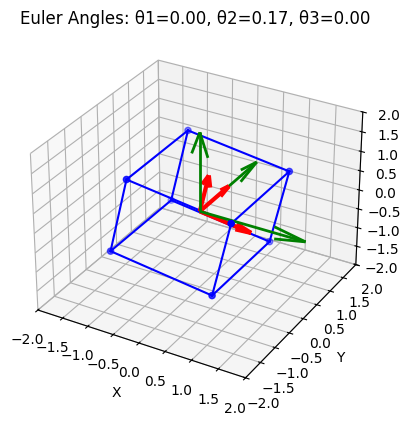

In [11]:
theta_1, theta_2, theta_3 = sm.symbols('theta_1, theta_2, theta_3')

N = ReferenceFrame('N')
B = ReferenceFrame('B')

B.orient_body_fixed(N, (theta_1, theta_2, theta_3), '321')

def rotation_matrix(theta_1, theta_2, theta_3):
    R1 = np.array([[1, 0, 0],
                   [0, np.cos(theta_1), -np.sin(theta_1)],
                   [0, np.sin(theta_1), np.cos(theta_1)]])
    
    R2 = np.array([[np.cos(theta_2), 0, np.sin(theta_2)],
                   [0, 1, 0],
                   [-np.sin(theta_2), 0, np.cos(theta_2)]])
    
    R3 = np.array([[np.cos(theta_3), -np.sin(theta_3), 0],
                   [np.sin(theta_3), np.cos(theta_3), 0],
                   [0, 0, 1]])

    return np.dot(R3, np.dot(R2, R1))

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Cube
vertices = np.array([[-1, -1, -1],
                     [ 1, -1, -1],
                     [ 1,  1, -1],
                     [-1,  1, -1],
                     [-1, -1,  1],
                     [ 1, -1,  1],
                     [ 1,  1,  1],
                     [-1,  1,  1]])

def update_plot(theta_1_val, theta_2_val, theta_3_val):
    ax.cla()
    
    R = rotation_matrix(theta_1_val, theta_2_val, theta_3_val)
    
    rotated_vertices = np.dot(vertices, R.T)
    
    ax.scatter(rotated_vertices[:, 0], rotated_vertices[:, 1], rotated_vertices[:, 2], color='b')

    edges = [
        [0, 1], [1, 2], [2, 3], [3, 0],
        [4, 5], [5, 6], [6, 7], [7, 4],
        [0, 4], [1, 5], [2, 6], [3, 7]
    ]
    
    for edge in edges:
        ax.plot([rotated_vertices[edge[0], 0], rotated_vertices[edge[1], 0]],
                [rotated_vertices[edge[0], 1], rotated_vertices[edge[1], 1]],
                [rotated_vertices[edge[0], 2], rotated_vertices[edge[1], 2]], color='b')

    ax.quiver(0, 0, 0, 2, 0, 0, color='g', linewidth=2)
    ax.quiver(0, 0, 0, 0, 2, 0, color='g', linewidth=2)
    ax.quiver(0, 0, 0, 0, 0, 2, color='g', linewidth=2)

    rotated_axes = np.dot(np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]]), R.T)
    ax.quiver(0, 0, 0, rotated_axes[0, 0], rotated_axes[0, 1], rotated_axes[0, 2], color='r', linewidth=3)
    ax.quiver(0, 0, 0, rotated_axes[1, 0], rotated_axes[1, 1], rotated_axes[1, 2], color='r', linewidth=3)
    ax.quiver(0, 0, 0, rotated_axes[2, 0], rotated_axes[2, 1], rotated_axes[2, 2], color='r', linewidth=3)

    ax.set_xlim([-2, 2])
    ax.set_ylim([-2, 2])
    ax.set_zlim([-2, 2])
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f'Euler Angles: θ1={theta_1_val:.2f}, θ2={theta_2_val:.2f}, θ3={theta_3_val:.2f}')
    
    plt.draw()

def animate(i):
    theta_1_val = np.radians(10 * np.sin(i * 0.1))
    theta_2_val = np.radians(10 * np.cos(i * 0.1))
    theta_3_val = np.radians(10 * np.sin(i * 0.1))
    
    update_plot(theta_1_val, theta_2_val, theta_3_val)

ani = animation.FuncAnimation(fig, animate, frames=200, interval=50)

ani.save('euler.gif', writer='imagemagick', fps=30)